# Goals
1. Design actionable, data-driven customer segmentation strategies
    1. Understand spending patterns
    2. Group similar customers (Segmentation)
    3. Profile customer segments
    4. Propose personalized marketing strategies

# Setup and Initialization

In [3]:
# Import the libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples
from matplotlib import cm
from scipy.stats import skew
from sklearn.preprocessing import MinMaxScaler

pd.options.display.max_columns = None
pd.options.display.max_rows = None

sns.set_style("ticks")
sns.color_palette(palette='magma')

[(0.135053, 0.068391, 0.315),
 (0.372116, 0.092816, 0.499053),
 (0.594508, 0.175701, 0.501241),
 (0.828886, 0.262229, 0.430644),
 (0.973381, 0.46152, 0.361965),
 (0.997341, 0.733545, 0.505167)]

In [ ]:
# Load the dataset
df = pd.read_csv("/Users/jhonchristianrozano/Documents/Programming/Python Programming/machine-learning-projects/customer-segmentation/data")
df.head(5)

,cc_num,year,month,HOM_tag,HOM_total,HOM_entertainment,HOM_entertainment_freq,HOM_food_dining,HOM_food_dining_freq,HOM_gas_transport,HOM_gas_transport_freq,HOM_grocery_net,HOM_grocery_net_freq,HOM_grocery_pos,HOM_grocery_pos_freq,HOM_health_fitness,HOM_health_fitness_freq,HOM_home,HOM_home_freq,HOM_kids_pets,HOM_kids_pets_freq,HOM_misc_net,HOM_misc_net_freq,HOM_misc_pos,HOM_misc_pos_freq,HOM_personal_care,HOM_personal_care_freq,HOM_shopping_net,HOM_shopping_net_freq,HOM_shopping_pos,HOM_shopping_pos_freq,HOM_travel,HOM_travel_freq,next_HOM_total,dob,gender,job
0,2703186189652095,2019,1,1,2904.31,218.73,4,90.69,3,67.67,1,190.30,3,807.92,4,22.61,1,153.49,2,262.69,5,160.49,5,4.05,1,215.16,5,557.81,5,140.54,7,12.16,2,5513.39,1988-03-09,F,"Psychologist, counselling"
1,2703186189652095,2019,1,2,5513.39,476.50,7,152.08,2,0.00,0,250.94,4,618.95,3,23.15,1,505.36,6,102.93,3,143.46,3,554.01,3,100.88,4,1941.28,6,620.88,5,22.97,3,3696.99,1988-03-09,F,"Psychologist, counselling"
2,2703186189652095,2019,2,1,3696.99,244.19,2,22.93,1,0.00,0,225.23,3,625.63,3,364.46,3,294.35,5,91.65,1,73.50,1,133.35,6,22.00,1,1422.89,2,176.81,7,0.00,0,2847.65,1988-03-09,F,"Psychologist, counselling"
3,2703186189652095,2019,2,2,2847.65,85.84,2,317.45,6,0.00,0,73.49,1,746.36,4,68.87,3,138.63,3,105.88,2,0.00,0,156.40,3,180.44,2,216.05,3,758.24,4,0.00,0,4785.08,1988-03-09,F,"Psychologist, counselling"
4,2703186189652095,2019,3,1,4785.08,245.70,3,51.88,2,152.95,2,111.16,2,1500.49,7,0.00,0,459.99,8,288.64,5,394.23,2,370.44,4,327.45,6,584.38,1,297.77,9,0.00,0,4127.63,1988-03-09,F,"Psychologist, counselling"


In [5]:
# Check the size of the shape
print("Shape:", df.shape)

# Check for the nulls
print("Missing values:", df.isnull().sum().sum())

# Check for the number of unique customers
print("Unique customers:", df['cc_num'].nunique())

# Check for the duplicated rows
print("Duplicated rows:", df.duplicated().sum())

Shape: (42676, 37)
Missing values: 0
Unique customers: 908
Duplicated rows: 0


### Inferences
- The dataframe has 42,676 rows and 37 columns.
- There are no missing values in the dataframe.
- The number of unique customers is 908.
- There are no duplicated rows.

The data is somehow already cleaned upon checking.

In [6]:
df.info()

# Change the datatype of cc_num to string as described in the Pdf_filtered file
df['cc_num'] = df['cc_num'].astype(str)
df['dob'] = pd.to_datetime(df['dob'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42676 entries, 0 to 42675
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cc_num                   42676 non-null  int64  
 1   year                     42676 non-null  int64  
 2   month                    42676 non-null  int64  
 3   HOM_tag                  42676 non-null  int64  
 4   HOM_total                42676 non-null  float64
 5   HOM_entertainment        42676 non-null  float64
 6   HOM_entertainment_freq   42676 non-null  int64  
 7   HOM_food_dining          42676 non-null  float64
 8   HOM_food_dining_freq     42676 non-null  int64  
 9   HOM_gas_transport        42676 non-null  float64
 10  HOM_gas_transport_freq   42676 non-null  int64  
 11  HOM_grocery_net          42676 non-null  float64
 12  HOM_grocery_net_freq     42676 non-null  int64  
 13  HOM_grocery_pos          42676 non-null  float64
 14  HOM_grocery_pos_freq  

### Inferences
The dataset consists of 42,676 entries with 37 columns altogether, and there is no missing value in the dataset. The following is a brief overview of the columns, which is also described in the PDF file. 

| **Variable**            | **Data Type** | **Description**                                                                 |
|-------------------------|---------------|----------------------------------------------------------------------------------|
| `cc_num`                | `str`         | Credit card number / customer ID                                                |
| `year`                  | `int`         | Year of transaction                                                              |
| `month`                 | `int`         | Month of transaction                                                             |
| `HOM_tag`               | `int`         | Half of Month (HOM) tag. HOM=1 refers to days 1 to 15, HOM=2 refers to days 16 to 30/31 |
| `HOM_total`             | `float`       | Sum of all transactions in one HOM                                              |
| `HOM_{category}`        | `float`       | Subtotal of transactions per spending type/category (see list of categories below) |
| `HOM_{category}_freq`   | `int`         | Frequency of transactions per category within the HOM period                    |
| `dob`                   | `datetime`    | Date of birth                                                                    |
| `gender`                | `str`         | Sex assigned at birth: M/F                                                      |
| `job`                   | `str`         | Job/description of customer                                                      |
| `next_HOM`              | `float`       | Sum of transactions for the next HOM                                            |

---

### **Other Notes:**

- **Spending category** may be any of the following:

  `entertainment`, `food_dining`, `gas_transport`, `grocery`, `health_fitness`,  
  `home`, `kids_pets`, `misc`, `personal_care`, `shopping`, `travel`

- `grocery` and `misc` have both `_net` (online) and `_pos` (point of sale) transactions.

In [7]:
# Get the summary statistics for the numerical variables
df.describe().T.map(lambda x: f"{x:.4e}")

,count,mean,min,25%,50%,75%,max,std
year,4.2676e+04,2.0195e+03,2.0190e+03,2.0190e+03,2.0190e+03,2.0200e+03,2.0200e+03,4.9989e-01
month,4.2676e+04,6.3830e+00,1.0000e+00,3.0000e+00,6.0000e+00,9.0000e+00,1.2000e+01,3.3931e+00
HOM_tag,4.2676e+04,1.4894e+00,1.0000e+00,1.0000e+00,1.0000e+00,2.0000e+00,2.0000e+00,4.9989e-01
HOM_total,4.2676e+04,2.8096e+03,1.0560e+01,1.2752e+03,2.3008e+03,3.7190e+03,3.6508e+04,2.1527e+03
HOM_entertainment,4.2676e+04,1.9061e+02,0.0000e+00,3.4210e+01,1.2861e+02,2.7515e+02,2.3024e+03,2.1340e+02
HOM_entertainment_freq,4.2676e+04,3.0173e+00,0.0000e+00,1.0000e+00,2.0000e+00,4.0000e+00,2.7000e+01,2.5332e+00
HOM_food_dining,4.2676e+04,1.4994e+02,0.0000e+00,3.0207e+01,1.0877e+02,2.2298e+02,1.5165e+03,1.5467e+02
HOM_food_dining_freq,4.2676e+04,2.9460e+00,0.0000e+00,1.0000e+00,2.0000e+00,4.0000e+00,2.6000e+01,2.5460e+00
HOM_gas_transport,4.2676e+04,2.6892e+02,0.0000e+00,8.1880e+01,2.0926e+02,3.8638e+02,2.1996e+03,2.4032e+02
HOM_gas_transport_freq,4.2676e+04,4.2222e+00,0.0000e+00,1.0000e+00,3.0000e+00,6.0000e+00,3.4000e+01,3.8898e+00


In [8]:
# Get the summary statistics for the categorical variables
df.describe(include="object").T

,count,unique,top,freq
cc_num,42676,908,2703186189652095,47
gender,42676,2,F,21620
job,42676,475,Naval architect,282


### Inference
- Most of the customers are female.
- There are 475 jobs associated with the customers.

In [9]:
# Get the number of HOMs
num_homs = 42676/908
print(num_homs)

47.0


There are only 47 half-of-month entries which span the two-year (2019, 2020) period. Upon validating, there is no HOM data for the 2nd period of December in 2020. So we will keep the data as is and we will not aggregate the data by monthly level.

In [10]:
# Add a date column that combine the year, month, and day
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-' + df['HOM_tag'].map({1: '1', 2: '16'}))
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = 2021 - df['dob'].dt.year
df = df.drop(columns = ["year", "month", "HOM_tag", "dob"])
df.head(5)

,cc_num,HOM_total,HOM_entertainment,HOM_entertainment_freq,HOM_food_dining,HOM_food_dining_freq,HOM_gas_transport,HOM_gas_transport_freq,HOM_grocery_net,HOM_grocery_net_freq,HOM_grocery_pos,HOM_grocery_pos_freq,HOM_health_fitness,HOM_health_fitness_freq,HOM_home,HOM_home_freq,HOM_kids_pets,HOM_kids_pets_freq,HOM_misc_net,HOM_misc_net_freq,HOM_misc_pos,HOM_misc_pos_freq,HOM_personal_care,HOM_personal_care_freq,HOM_shopping_net,HOM_shopping_net_freq,HOM_shopping_pos,HOM_shopping_pos_freq,HOM_travel,HOM_travel_freq,next_HOM_total,gender,job,date,age
0,2703186189652095,2904.31,218.73,4,90.69,3,67.67,1,190.30,3,807.92,4,22.61,1,153.49,2,262.69,5,160.49,5,4.05,1,215.16,5,557.81,5,140.54,7,12.16,2,5513.39,F,"Psychologist, counselling",2019-01-01,33
1,2703186189652095,5513.39,476.50,7,152.08,2,0.00,0,250.94,4,618.95,3,23.15,1,505.36,6,102.93,3,143.46,3,554.01,3,100.88,4,1941.28,6,620.88,5,22.97,3,3696.99,F,"Psychologist, counselling",2019-01-16,33
2,2703186189652095,3696.99,244.19,2,22.93,1,0.00,0,225.23,3,625.63,3,364.46,3,294.35,5,91.65,1,73.50,1,133.35,6,22.00,1,1422.89,2,176.81,7,0.00,0,2847.65,F,"Psychologist, counselling",2019-02-01,33
3,2703186189652095,2847.65,85.84,2,317.45,6,0.00,0,73.49,1,746.36,4,68.87,3,138.63,3,105.88,2,0.00,0,156.40,3,180.44,2,216.05,3,758.24,4,0.00,0,4785.08,F,"Psychologist, counselling",2019-02-16,33
4,2703186189652095,4785.08,245.70,3,51.88,2,152.95,2,111.16,2,1500.49,7,0.00,0,459.99,8,288.64,5,394.23,2,370.44,4,327.45,6,584.38,1,297.77,9,0.00,0,4127.63,F,"Psychologist, counselling",2019-03-01,33


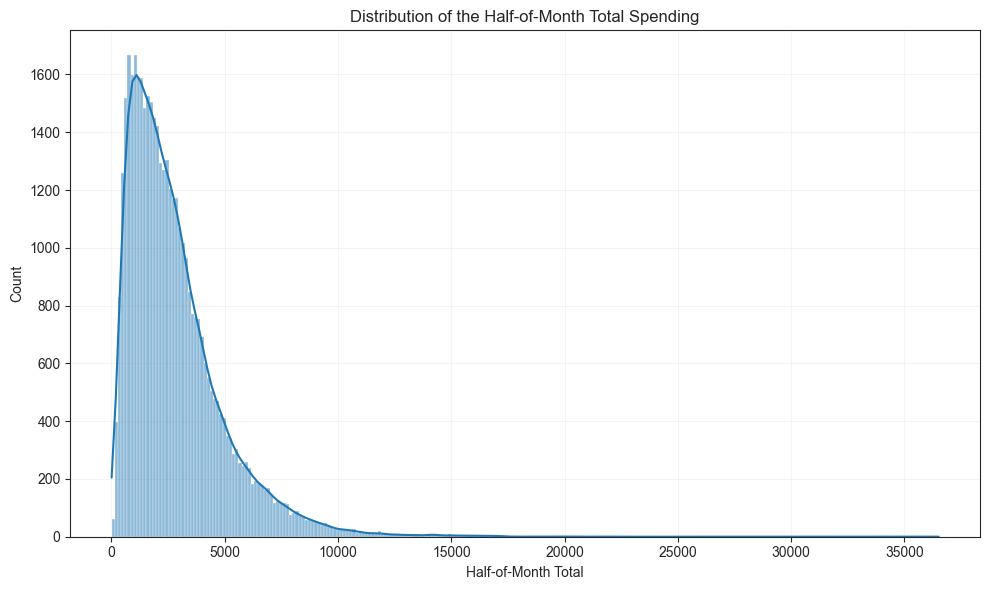

In [11]:
plt.figure(figsize=(10, 6), dpi=100)
sns.histplot(df['HOM_total'], kde=True)

plt.title("Distribution of the Half-of-Month Total Spending")
plt.xlabel("Half-of-Month Total")
plt.ylabel("Count")

plt.grid(True, alpha = 0.2)
plt.tight_layout()
plt.show()

### Inference
- Based on the figure above, the distribution is right-skewed. This means that most customers have **low to moderate** spending and only a few customers spend very high amounts.
- The values are mostly clustered between 0 and 5000.
- Very few customers have spending amounts above ~10,000 (outliers).

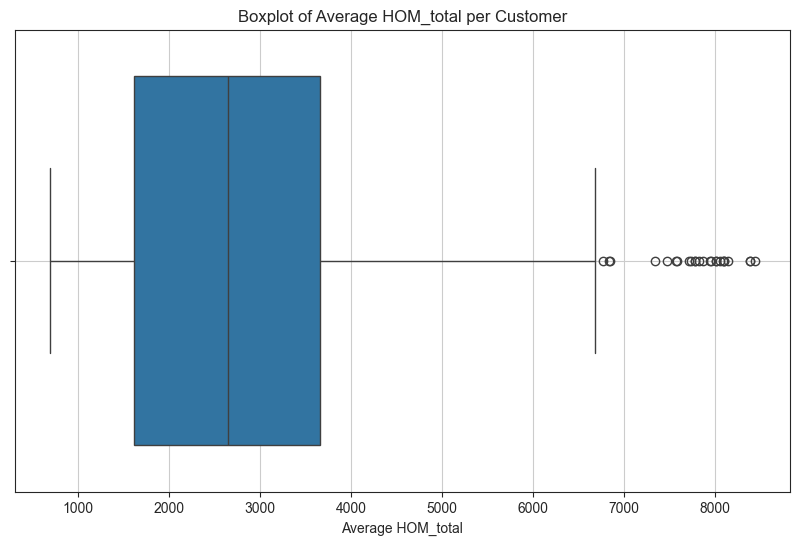

25


In [12]:
avg_hom_total = df.groupby('cc_num')['HOM_total'].mean().reset_index()
avg_hom_total.columns = ['cc_num', 'avg_HOM_total']

# Plot boxplot to visualize outliers
plt.figure(figsize=(10, 6), dpi=100)
sns.boxplot(x=avg_hom_total['avg_HOM_total'])
plt.title("Boxplot of Average HOM_total per Customer")
plt.xlabel("Average HOM_total")
plt.grid(True)
plt.show()

# Calculate IQR and identify outliers
Q1 = avg_hom_total['avg_HOM_total'].quantile(0.25)
Q3 = avg_hom_total['avg_HOM_total'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mark customers as outliers
avg_hom_total['is_outlier'] = (avg_hom_total['avg_HOM_total'] > upper_bound)

# Filter out outlier customers
non_outlier_customers = avg_hom_total[~avg_hom_total['is_outlier']]['cc_num']
df_filtered = df[df['cc_num'].isin(non_outlier_customers)].copy()

# Show number of removed outliers and preview of filtered data
removed_outliers = avg_hom_total['is_outlier'].sum()
print(removed_outliers)

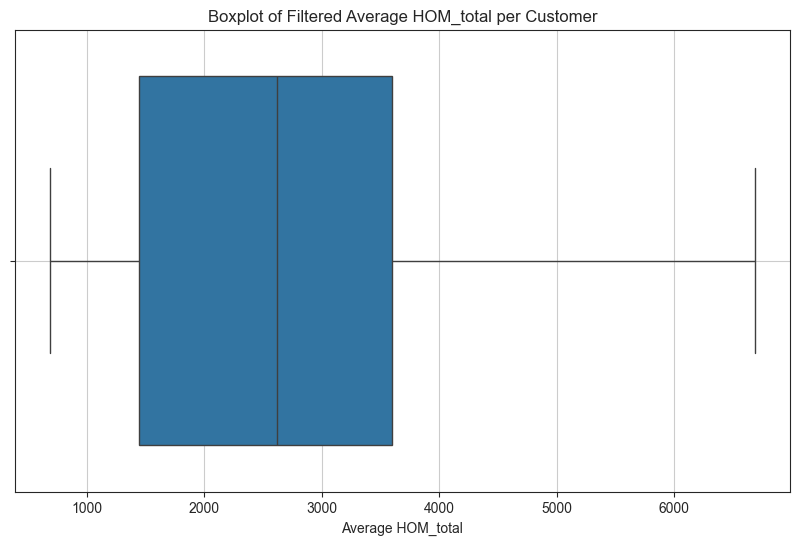

In [13]:
avg_hom_total = df_filtered.groupby('cc_num')['HOM_total'].mean().reset_index()
avg_hom_total.columns = ['cc_num', 'avg_HOM_total']

plt.figure(figsize=(10, 6), dpi=100)
sns.boxplot(x=avg_hom_total['avg_HOM_total'])
plt.title("Boxplot of Filtered Average HOM_total per Customer")
plt.xlabel("Average HOM_total")
plt.grid(True)
plt.show()

In [14]:
df_filtered.head(5)

,cc_num,HOM_total,HOM_entertainment,HOM_entertainment_freq,HOM_food_dining,HOM_food_dining_freq,HOM_gas_transport,HOM_gas_transport_freq,HOM_grocery_net,HOM_grocery_net_freq,HOM_grocery_pos,HOM_grocery_pos_freq,HOM_health_fitness,HOM_health_fitness_freq,HOM_home,HOM_home_freq,HOM_kids_pets,HOM_kids_pets_freq,HOM_misc_net,HOM_misc_net_freq,HOM_misc_pos,HOM_misc_pos_freq,HOM_personal_care,HOM_personal_care_freq,HOM_shopping_net,HOM_shopping_net_freq,HOM_shopping_pos,HOM_shopping_pos_freq,HOM_travel,HOM_travel_freq,next_HOM_total,gender,job,date,age
0,2703186189652095,2904.31,218.73,4,90.69,3,67.67,1,190.30,3,807.92,4,22.61,1,153.49,2,262.69,5,160.49,5,4.05,1,215.16,5,557.81,5,140.54,7,12.16,2,5513.39,F,"Psychologist, counselling",2019-01-01,33
1,2703186189652095,5513.39,476.50,7,152.08,2,0.00,0,250.94,4,618.95,3,23.15,1,505.36,6,102.93,3,143.46,3,554.01,3,100.88,4,1941.28,6,620.88,5,22.97,3,3696.99,F,"Psychologist, counselling",2019-01-16,33
2,2703186189652095,3696.99,244.19,2,22.93,1,0.00,0,225.23,3,625.63,3,364.46,3,294.35,5,91.65,1,73.50,1,133.35,6,22.00,1,1422.89,2,176.81,7,0.00,0,2847.65,F,"Psychologist, counselling",2019-02-01,33
3,2703186189652095,2847.65,85.84,2,317.45,6,0.00,0,73.49,1,746.36,4,68.87,3,138.63,3,105.88,2,0.00,0,156.40,3,180.44,2,216.05,3,758.24,4,0.00,0,4785.08,F,"Psychologist, counselling",2019-02-16,33
4,2703186189652095,4785.08,245.70,3,51.88,2,152.95,2,111.16,2,1500.49,7,0.00,0,459.99,8,288.64,5,394.23,2,370.44,4,327.45,6,584.38,1,297.77,9,0.00,0,4127.63,F,"Psychologist, counselling",2019-03-01,33


### Inferences
- Median spending is slightly higher among female customers.
- Both genders show similar ranges but with more high-value outliers on the female side.

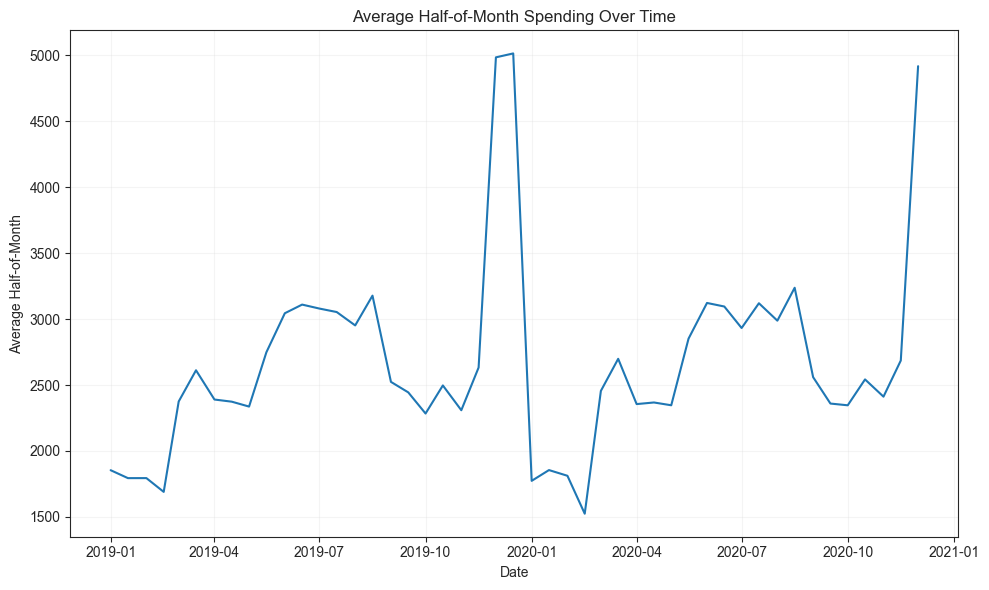

In [15]:
avg_spend_time = df_filtered.groupby('date')['HOM_total'].mean().reset_index()

plt.figure(figsize=(10, 6), dpi=100)
sns.lineplot(x='date', y='HOM_total', data=avg_spend_time)

plt.title("Average Half-of-Month Spending Over Time")
plt.xlabel("Date")
plt.ylabel("Average Half-of-Month")

plt.grid(True, alpha = 0.2)
plt.tight_layout()
plt.show()

### Inferences
- Shows seasonality and fluctuations in average spending.
- Clear peaks observed (e.g., around end-of-year holidays).

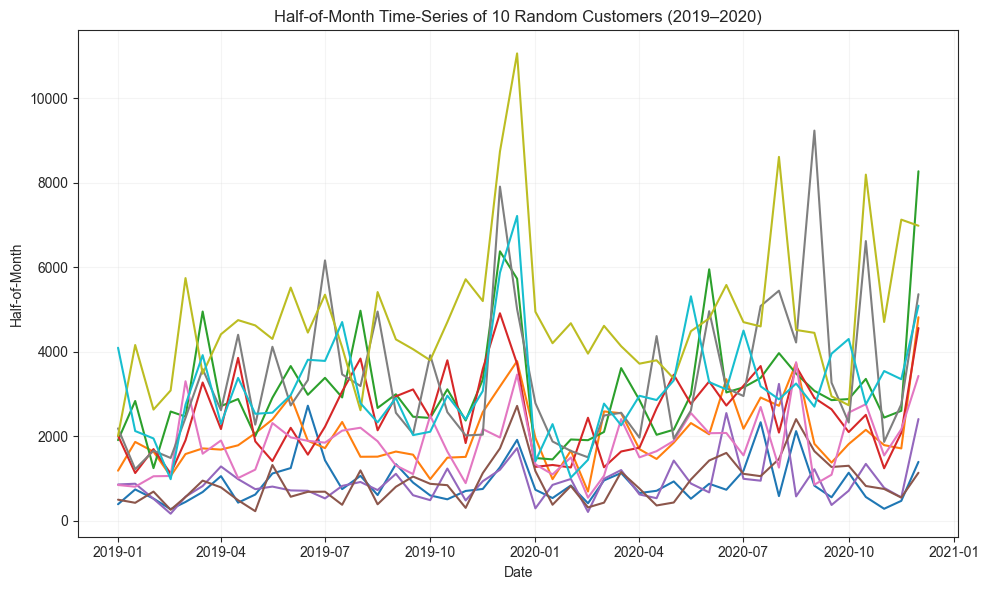

In [16]:
# Filter data from 2019 to 2020
mask = (df_filtered['date'] >= "2019-01-01") & (df['date'] < "2021-01-01")
df_filtered_date = df_filtered.loc[mask]
sample_customers = df_filtered_date['cc_num'].drop_duplicates().sample(10, random_state=42)

# Filter data for these customers
df_sample = df_filtered_date[df_filtered_date['cc_num'].isin(sample_customers)]

# Plot time-series of HOM_total per customer
plt.figure(figsize=(10, 6), dpi=100)
for cc in sample_customers:
    customer_data = df_sample[df_sample['cc_num'] == cc]
    plt.plot(customer_data['date'], customer_data['HOM_total'])

plt.title("Half-of-Month Time-Series of 10 Random Customers (2019–2020)")
plt.xlabel("Date")
plt.ylabel("Half-of-Month")

plt.grid(True, alpha = 0.2)
plt.tight_layout()
plt.show()

### Inferences
- Diverse spending behaviors: some are stable, some highly variable.
- Spikes during end-of-year periods.
- Temporary dips in early 2020, likely related to pandemic-related slowdowns.

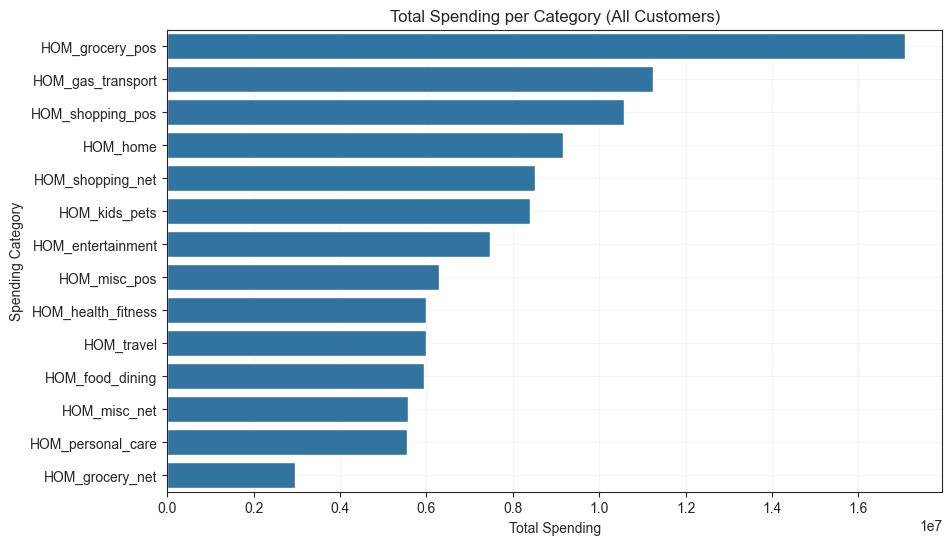

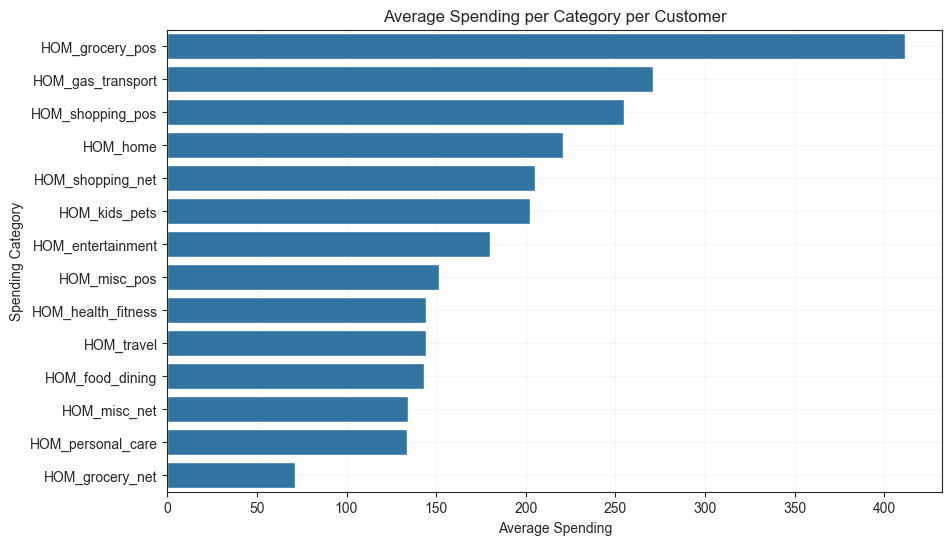

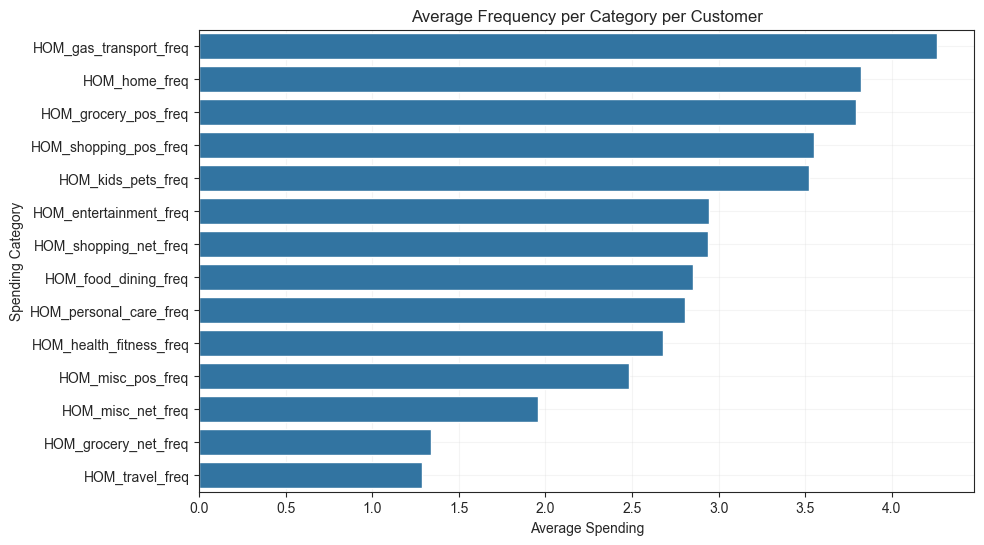

In [17]:
# Select the categories of spending in df
category_cols = [col for col in df_filtered.columns if col.startswith("HOM_") 
                 and not col.endswith("_freq") 
                 and col not in ['HOM_total', 'HOM_tag']]
freq_cols = [col for col in df_filtered.columns if col.endswith('_freq')]

# Total spending per category
total_spend = df_filtered[category_cols].sum().sort_values(ascending=False)

# Average per customer
average_spend = df_filtered.groupby('cc_num')[category_cols].mean().mean().sort_values(ascending=False)

# Average frequency per category
average_freq = df_filtered.groupby('cc_num')[freq_cols].mean().mean().sort_values(ascending=False)

# Plot total spending
plt.figure(figsize=(10, 6), dpi=100)
sns.barplot(x=total_spend.values, y=total_spend.index)
plt.title("Total Spending per Category (All Customers)")
plt.xlabel("Total Spending")
plt.ylabel("Spending Category")

plt.grid(True, alpha = 0.2)
plt.show()

# Plot average per customer
plt.figure(figsize=(10, 6), dpi=100)
sns.barplot(x=average_spend.values, y=average_spend.index)
plt.title("Average Spending per Category per Customer")
plt.xlabel("Average Spending")
plt.ylabel("Spending Category")

plt.grid(True, alpha = 0.2)
plt.show()

# Plot average frequency per category
# Plot average per customer
plt.figure(figsize=(10, 6), dpi=100)
sns.barplot(x=average_freq.values, y=average_freq.index)
plt.title("Average Frequency per Category per Customer")
plt.xlabel("Average Spending")
plt.ylabel("Spending Category")

plt.grid(True, alpha = 0.2)
plt.show()

### Inferences
Total Spending per Category (All Customers)
1. HOM_grocery_pos 
2. HOM_shopping_pos
3. HOM_gas_transport
4. HOM_home
5. HOM_shopping_net
6. HOM_kids_pets
7. HOM_entertainment

Average Spending per Category per Customer
1. HOM_grocery_pos 
2. HOM_shopping_pos
3. HOM_gas_transport
4. HOM_home
5. HOM_shopping_net
6. HOM_kids_pets
7. HOM_entertainment

Average Spending per Category per Customer
1. HOM_grocery_pos 
2. HOM_shopping_pos
3. HOM_gas_transport
4. HOM_home
5. HOM_shopping_net
6. HOM_kids_pets
7. HOM_entertainment


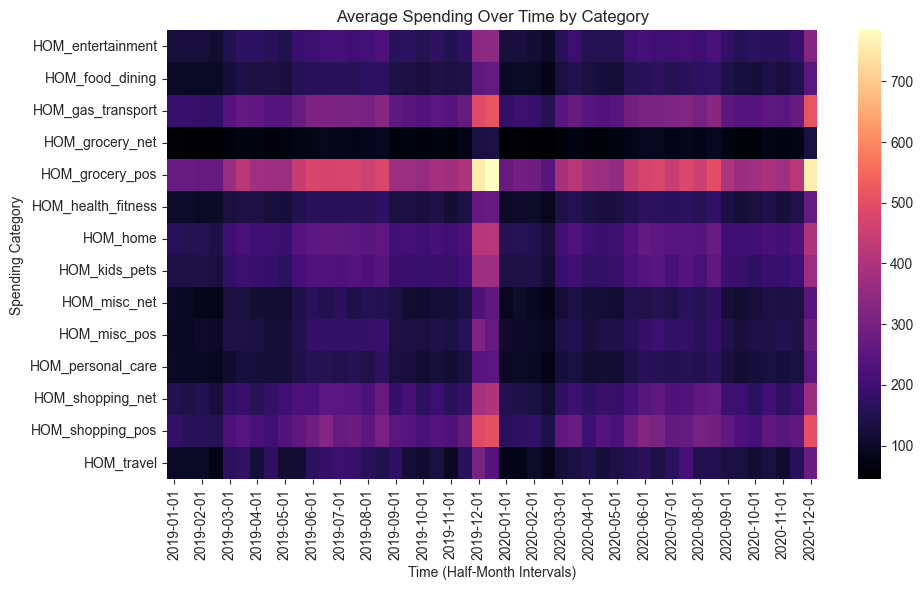

In [18]:
category_time_avg = df_filtered.groupby('date')[category_cols].mean()
category_time_avg.index = category_time_avg.index.strftime('%Y-%m-%d')

# Create a heatmap
plt.figure(figsize=(10, 6), dpi=100)
sns.heatmap(category_time_avg.T, cmap="magma")
plt.title("Average Spending Over Time by Category")
plt.xlabel("Time (Half-Month Intervals)")
plt.ylabel("Spending Category")

plt.tight_layout()
plt.show()

### Inferences
There are spikes (high spending) around December and January, especially for:
- `HOM_grocery_pos`
- `HOM_shopping_pos`
- `HOM_gas_transport`

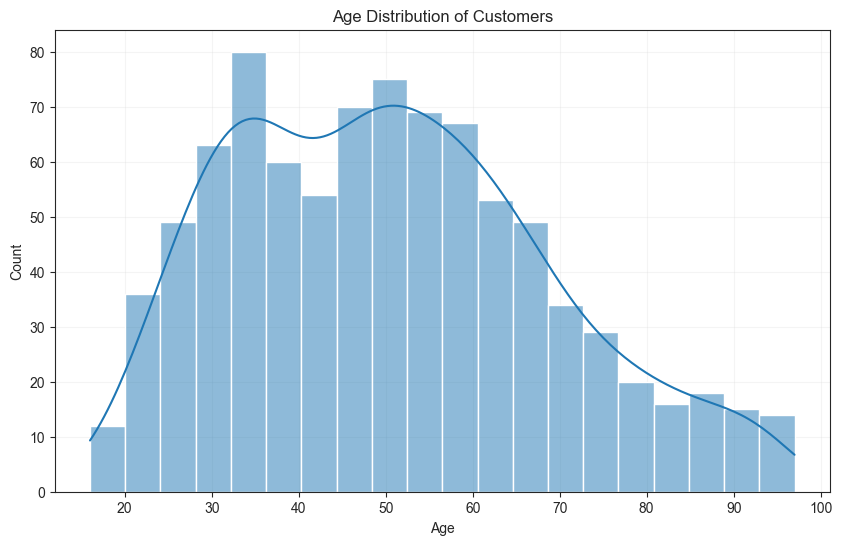

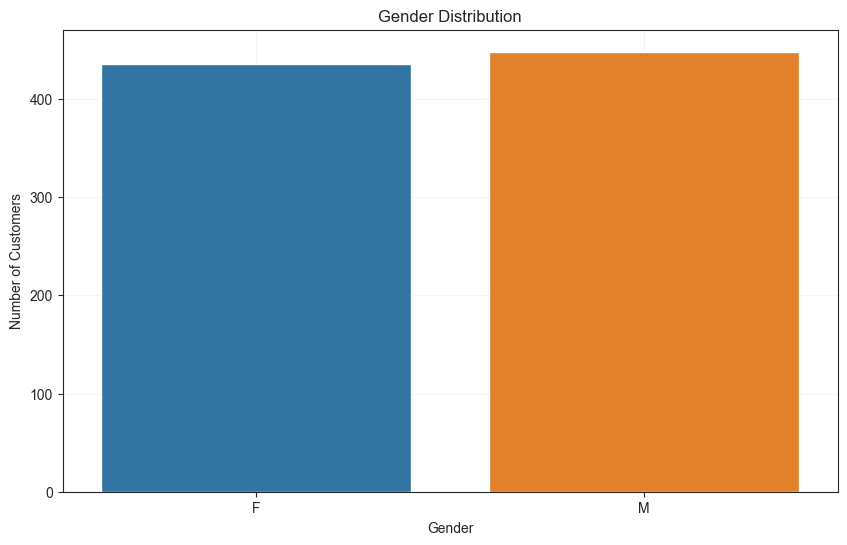

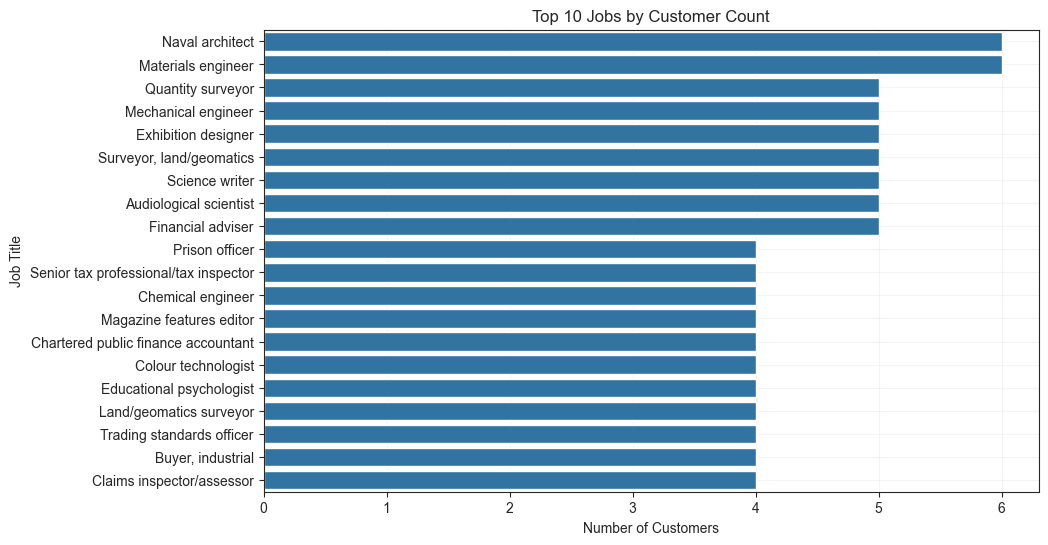

In [19]:
df_unique = df_filtered.drop_duplicates(subset='cc_num')

# Age distribution
plt.figure(figsize=(10, 6), dpi=100)
sns.histplot(df_unique['age'], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")

plt.grid(True, alpha = 0.2)
plt.show()

# Gender distribution
plt.figure(figsize=(10, 6), dpi=100)
sns.countplot(x='gender', data=df_unique, hue='gender', legend=False)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.grid(True, alpha = 0.2)
plt.show()

# Top 0 Jobs by Customer Count
top_jobs = df_unique['job'].value_counts().nlargest(20)
plt.figure(figsize=(10, 6), dpi=100)
sns.barplot(x=top_jobs.values, y=top_jobs.index)
plt.title("Top 10 Jobs by Customer Count")
plt.xlabel("Number of Customers")
plt.ylabel("Job Title")

plt.grid(True, alpha = 0.2)
plt.show()

### Inferences
- The age range of customers spans from ~20 to 100, with peaks around 40–60 years old.
- The gender distribution is fairly balanced, with a slight female majority.
- Diverse job roles are represented, each with 5–6 individuals.

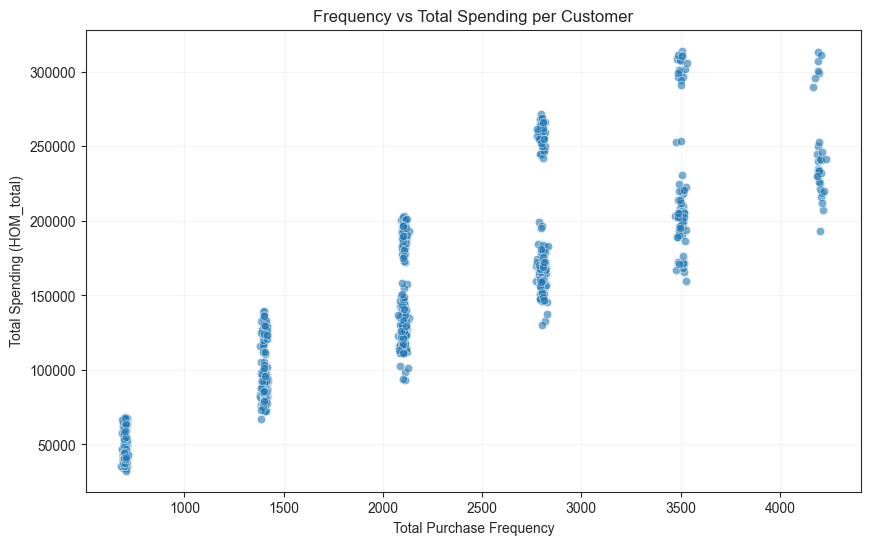

In [20]:
# Extract frequency columns (those ending with '_freq')
freq_cols = [col for col in df_filtered.columns if col.endswith('_freq')]

# Group by customer and sum HOM_total and total frequency
customer_spend_freq = df_filtered.groupby('cc_num').agg({
    'HOM_total': 'sum',
    **{col: 'sum' for col in freq_cols}
})

# Add total frequency column
customer_spend_freq['total_frequency'] = customer_spend_freq[freq_cols].sum(axis=1)

# Scatterplot: HOM_total vs total_frequency
plt.figure(figsize=(10, 6), dpi=100)
sns.scatterplot(data=customer_spend_freq, x='total_frequency', y='HOM_total', alpha=0.6)
plt.title("Frequency vs Total Spending per Customer")
plt.xlabel("Total Purchase Frequency")
plt.ylabel("Total Spending (HOM_total)")

plt.grid(True, alpha=0.2)
plt.show()


### Inferences
- There is a strong positive trend: customers who purchase more frequently also tend to spend more.
- A few high-frequency, high-spending group of customers are visible
- The relationship supports the hypothesis that frequent buyers tend to spend more.

# Feature Engineering

In [22]:
# Define base features: age, gender, and spending stability
base_agg = df_filtered.groupby('cc_num').agg(
    spending_std=('HOM_total', 'std'),
    age=('age', 'first'),
    gender=('gender', 'first')
)

# Calculate spending preference (percentage of total spend per category)
category_cols = [col for col in df_filtered.columns if col.startswith("HOM_") and not col.endswith("_freq") and col not in ['HOM_total', 'next_HOM_total']]

# Group by customer and sum up all transactions to get totals
customer_sums = df_filtered.drop(columns=['date', 'gender']).groupby('cc_num').sum()
total_spend_per_customer = customer_sums['HOM_total']

# Calculate the percentage of total spend for each category
category_percent = customer_sums[category_cols].div(total_spend_per_customer, axis=0)
category_percent.columns = [col + '_pct' for col in category_percent.columns]

# Add 'Average Transaction Value' feature
freq_cols = [col for col in df_filtered.columns if col.endswith("_freq")]
customer_spend_totals = customer_sums[category_cols]
customer_freq_totals = customer_sums[freq_cols]

# Create an empty DataFrame to hold the new features
avg_tx_value_features = pd.DataFrame(index=customer_spend_totals.index)

# Loop through each spending category to calculate its average transaction value
for cat_col in category_cols:
    freq_col = cat_col + '_freq'
    if freq_col in customer_freq_totals.columns:
        new_col_name = 'avg_tx_val_' + cat_col

        # Calculate avg transaction value, adding a small epsilon to prevent division by zero
        avg_tx_value_features[new_col_name] = customer_spend_totals[cat_col] / (customer_freq_totals[freq_col] + 1e-6)


# Create a feature that includes online vs. in-store preference ratio
pos_cols = [col for col in category_cols if col.endswith('_pos')]
net_cols = [col for col in category_cols if col.endswith('_net')]

# Use the customer_sums DataFrame we already created
total_net_spend = customer_sums[net_cols].sum(axis=1)
online_spend_ratio = total_net_spend / (total_spend_per_customer + 1e-6)
online_spend_ratio.name = 'online_spend_ratio'

# Concatenate the dataframe features
customer_features = pd.concat([
    base_agg,
    category_percent,
    avg_tx_value_features,
    online_spend_ratio
], axis=1)

# Map gender to a numeric format
customer_features['gender'] = customer_features['gender'].map({'F': 0, 'M': 1})

# Handle any potential NaN values that resulted from calculations (e.g., std for customers with one transaction)
customer_features.fillna(0, inplace=True)

customer_features.head(5)

,spending_std,age,gender,HOM_entertainment_pct,HOM_food_dining_pct,HOM_gas_transport_pct,HOM_grocery_net_pct,HOM_grocery_pos_pct,HOM_health_fitness_pct,HOM_home_pct,HOM_kids_pets_pct,HOM_misc_net_pct,HOM_misc_pos_pct,HOM_personal_care_pct,HOM_shopping_net_pct,HOM_shopping_pos_pct,HOM_travel_pct,avg_tx_val_HOM_entertainment,avg_tx_val_HOM_food_dining,avg_tx_val_HOM_gas_transport,avg_tx_val_HOM_grocery_net,avg_tx_val_HOM_grocery_pos,avg_tx_val_HOM_health_fitness,avg_tx_val_HOM_home,avg_tx_val_HOM_kids_pets,avg_tx_val_HOM_misc_net,avg_tx_val_HOM_misc_pos,avg_tx_val_HOM_personal_care,avg_tx_val_HOM_shopping_net,avg_tx_val_HOM_shopping_pos,avg_tx_val_HOM_travel,online_spend_ratio
cc_num,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
180011453250192,1841.642883,28,1,0.072025,0.048964,0.028790,0.020551,0.127132,0.051643,0.101759,0.050194,0.023312,0.029415,0.031377,0.070156,0.128518,0.216164,75.185836,60.256697,69.582612,50.120909,100.019355,74.889837,79.129536,50.246119,104.233332,34.917035,75.157231,95.056464,134.681757,495.657175,0.114018
180014262259255,815.361363,63,0,0.073827,0.111077,0.112178,0.020094,0.140028,0.028532,0.091464,0.148561,0.035917,0.037246,0.048929,0.049308,0.098875,0.003965,68.388853,84.426324,70.750141,85.093329,89.586186,37.312794,61.155864,83.615443,74.279301,37.216404,41.048585,69.601110,55.650822,5.596190,0.105319
180017442990269,669.890404,82,0,0.054310,0.097009,0.119842,0.025108,0.144013,0.026413,0.098001,0.115372,0.025748,0.057708,0.056158,0.087869,0.085272,0.007177,47.269300,75.386160,70.956326,91.054163,90.174963,32.841428,62.259854,74.936492,54.659267,55.807555,46.111415,107.715351,45.813148,9.463939,0.138726
180018375329178,1371.831200,33,0,0.075605,0.046146,0.031473,0.039618,0.217915,0.046846,0.061881,0.066970,0.039484,0.076082,0.046035,0.111858,0.136232,0.003857,101.601999,54.011419,73.202691,59.401157,200.682283,62.953777,59.086894,64.971550,76.204786,94.539794,56.430405,94.387767,97.304645,14.887872,0.190960
180031190491743,2257.790127,49,0,0.075310,0.046714,0.022325,0.040689,0.216268,0.045917,0.072688,0.057464,0.057751,0.060066,0.042789,0.101868,0.137352,0.022798,103.746622,63.517575,70.120099,60.569336,198.619590,60.092958,61.044813,62.888327,107.971726,82.385502,52.294241,89.876517,105.738088,92.996492,0.200309


In [23]:
corr_matrix = customer_features.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than your threshold (e.g., 0.8)
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print("Features to consider for removal due to high correlation:")
print(to_drop)

# To see the specific pairs:
for col in upper.columns:
    correlated_features = upper.index[upper[col] > 0.8].tolist()
    if correlated_features:
        print(f"Feature '{col}' is highly correlated with: {correlated_features}")

Features to consider for removal due to high correlation:
['avg_tx_val_HOM_food_dining', 'avg_tx_val_HOM_grocery_net', 'avg_tx_val_HOM_grocery_pos', 'avg_tx_val_HOM_kids_pets', 'avg_tx_val_HOM_shopping_pos', 'avg_tx_val_HOM_travel']
Feature 'avg_tx_val_HOM_food_dining' is highly correlated with: ['HOM_food_dining_pct']
Feature 'avg_tx_val_HOM_grocery_net' is highly correlated with: ['HOM_food_dining_pct', 'avg_tx_val_HOM_food_dining']
Feature 'avg_tx_val_HOM_grocery_pos' is highly correlated with: ['HOM_grocery_pos_pct']
Feature 'avg_tx_val_HOM_kids_pets' is highly correlated with: ['HOM_food_dining_pct', 'avg_tx_val_HOM_grocery_net']
Feature 'avg_tx_val_HOM_shopping_pos' is highly correlated with: ['HOM_shopping_pos_pct']
Feature 'avg_tx_val_HOM_travel' is highly correlated with: ['HOM_travel_pct']


In [24]:
# List of features to remove 
features_to_drop = ['avg_tx_val_HOM_food_dining', 'avg_tx_val_HOM_grocery_net', 'avg_tx_val_HOM_grocery_pos', 'avg_tx_val_HOM_kids_pets', 'avg_tx_val_HOM_shopping_pos', 'avg_tx_val_HOM_travel']

customer_features = customer_features.drop(columns=features_to_drop)
customer_features.head()

,spending_std,age,gender,HOM_entertainment_pct,HOM_food_dining_pct,HOM_gas_transport_pct,HOM_grocery_net_pct,HOM_grocery_pos_pct,HOM_health_fitness_pct,HOM_home_pct,HOM_kids_pets_pct,HOM_misc_net_pct,HOM_misc_pos_pct,HOM_personal_care_pct,HOM_shopping_net_pct,HOM_shopping_pos_pct,HOM_travel_pct,avg_tx_val_HOM_entertainment,avg_tx_val_HOM_gas_transport,avg_tx_val_HOM_health_fitness,avg_tx_val_HOM_home,avg_tx_val_HOM_misc_net,avg_tx_val_HOM_misc_pos,avg_tx_val_HOM_personal_care,avg_tx_val_HOM_shopping_net,online_spend_ratio
cc_num,,,,,,,,,,,,,,,,,,,,,,,,,,
180011453250192,1841.642883,28,1,0.072025,0.048964,0.028790,0.020551,0.127132,0.051643,0.101759,0.050194,0.023312,0.029415,0.031377,0.070156,0.128518,0.216164,75.185836,69.582612,74.889837,79.129536,104.233332,34.917035,75.157231,95.056464,0.114018
180014262259255,815.361363,63,0,0.073827,0.111077,0.112178,0.020094,0.140028,0.028532,0.091464,0.148561,0.035917,0.037246,0.048929,0.049308,0.098875,0.003965,68.388853,70.750141,37.312794,61.155864,74.279301,37.216404,41.048585,69.601110,0.105319
180017442990269,669.890404,82,0,0.054310,0.097009,0.119842,0.025108,0.144013,0.026413,0.098001,0.115372,0.025748,0.057708,0.056158,0.087869,0.085272,0.007177,47.269300,70.956326,32.841428,62.259854,54.659267,55.807555,46.111415,107.715351,0.138726
180018375329178,1371.831200,33,0,0.075605,0.046146,0.031473,0.039618,0.217915,0.046846,0.061881,0.066970,0.039484,0.076082,0.046035,0.111858,0.136232,0.003857,101.601999,73.202691,62.953777,59.086894,76.204786,94.539794,56.430405,94.387767,0.190960
180031190491743,2257.790127,49,0,0.075310,0.046714,0.022325,0.040689,0.216268,0.045917,0.072688,0.057464,0.057751,0.060066,0.042789,0.101868,0.137352,0.022798,103.746622,70.120099,60.092958,61.044813,107.971726,82.385502,52.294241,89.876517,0.200309


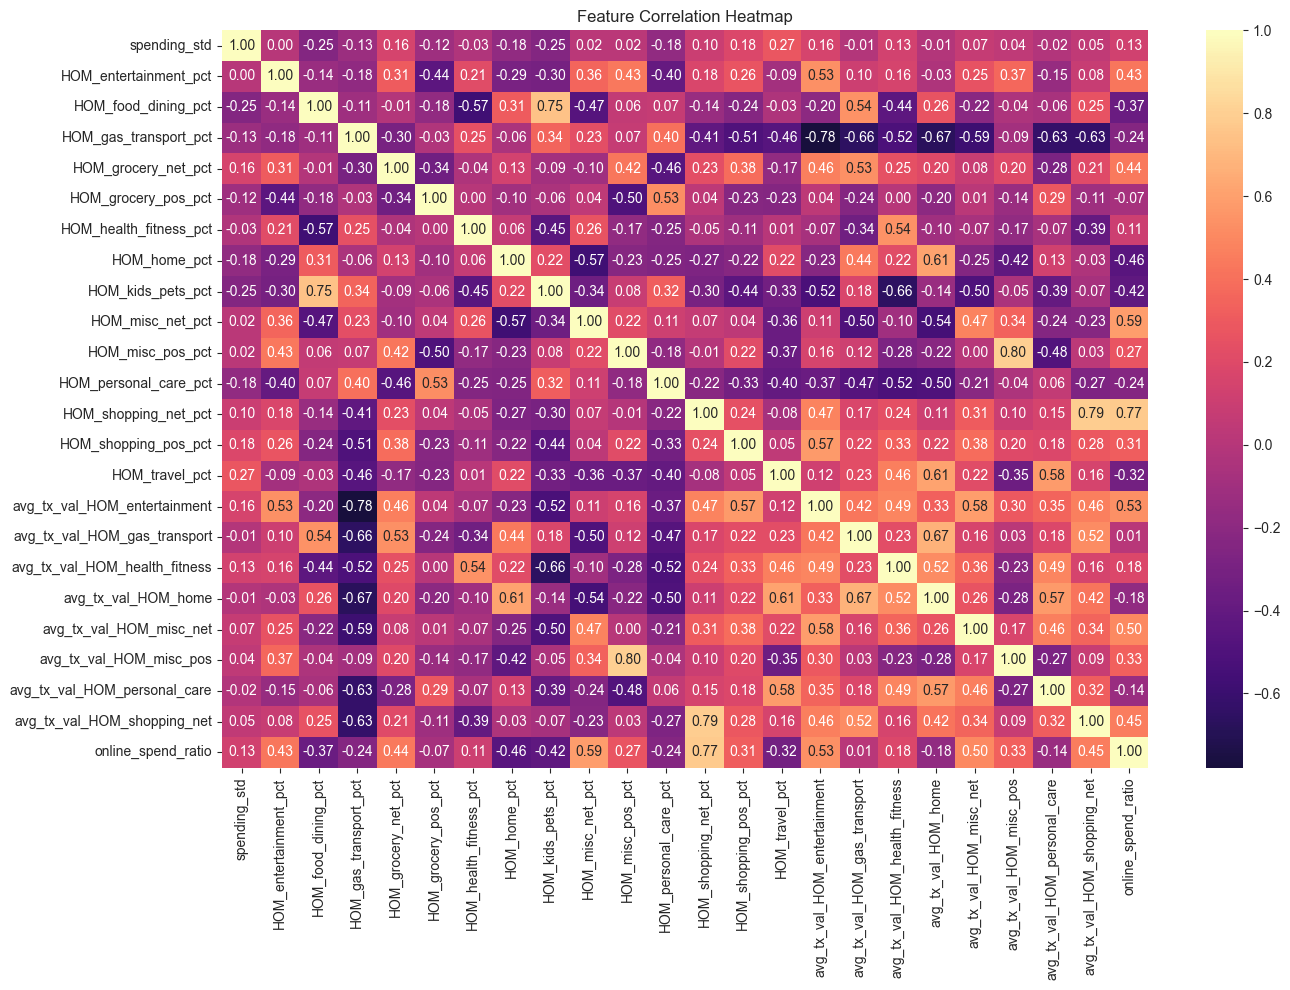

In [25]:
# Drop non-numeric or identifier columns if any (e.g., gender already encoded, so it's okay)
corr_matrix = customer_features.drop(columns=['age', 'gender']).corr()

# Set up the figure
plt.figure(figsize=(14, 10), dpi=100)

# Draw the heatmap with annotations and a color bar
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='magma', center=0)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# # Compute skewness of each feature (excluding 'gender' or other categorical variables)
# numeric_cols = customer_features.select_dtypes(include=[np.number]).columns.drop('gender', errors='ignore')
# skewed_cols = customer_features[numeric_cols].apply(skew)

# # Select only highly skewed features (absolute skewness > 1)
# highly_skewed = skewed_cols[abs(skewed_cols) > 1].index

# # Apply log1p to those columns
# customer_features[highly_skewed] = customer_features[highly_skewed].apply(np.log1p)


In [26]:
scaler = StandardScaler()
features_to_scale = customer_features.drop(columns=['gender']).columns
X_scaled = scaler.fit_transform(customer_features[features_to_scale])

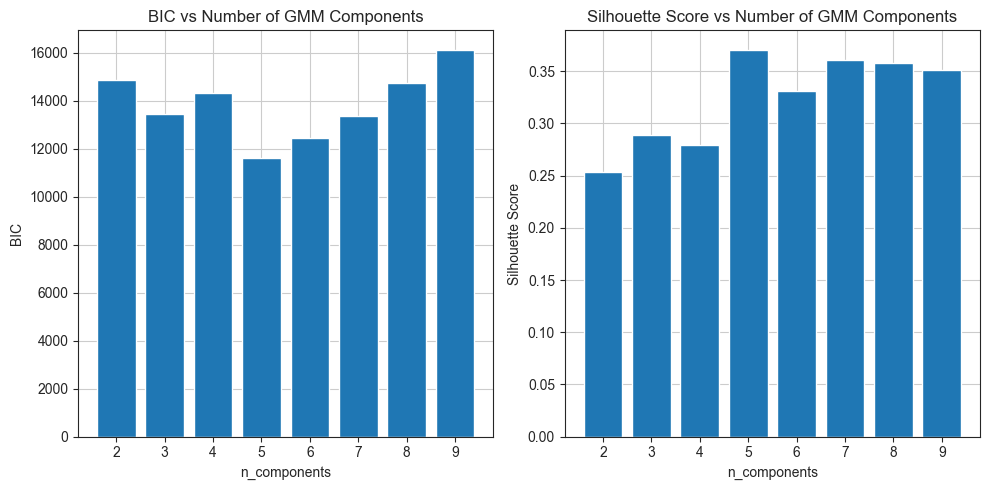

In [27]:
X_gmm = X_scaled

n_range = range(2, 10)
bic_scores = []
silhouette_scores = []

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=111)
    labels = gmm.fit_predict(X_gmm)

    bic_scores.append(gmm.bic(X_gmm))
    silhouette_scores.append(silhouette_score(X_gmm, labels))

# Plot BIC and Silhouette Score
plt.figure(figsize=(10, 5), dpi=100)

plt.subplot(1, 2, 1)
plt.bar(n_range, bic_scores)
plt.title('BIC vs Number of GMM Components')
plt.xlabel('n_components')
plt.ylabel('BIC')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(n_range, silhouette_scores)
plt.title('Silhouette Score vs Number of GMM Components')
plt.xlabel('n_components')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

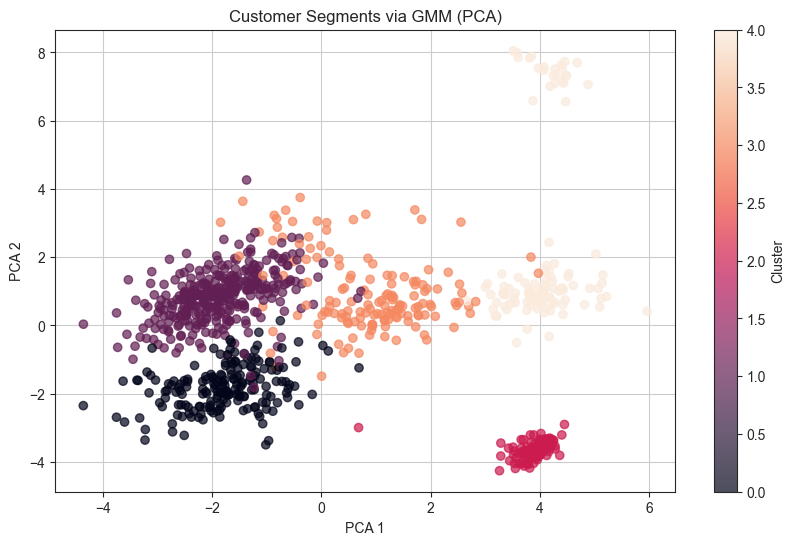

In [48]:
best_n = silhouette_scores.index(max(silhouette_scores)) + 2  # because range starts at 2
final_gmm = GaussianMixture(n_components=best_n, random_state=42)
customer_features['cluster'] = final_gmm.fit_predict(X_gmm)

# Reduce features to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_gmm)

# Plot clusters
plt.figure(figsize=(10, 6), dpi=100)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_features['cluster'], alpha=0.7)
plt.title('Customer Segments via GMM (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

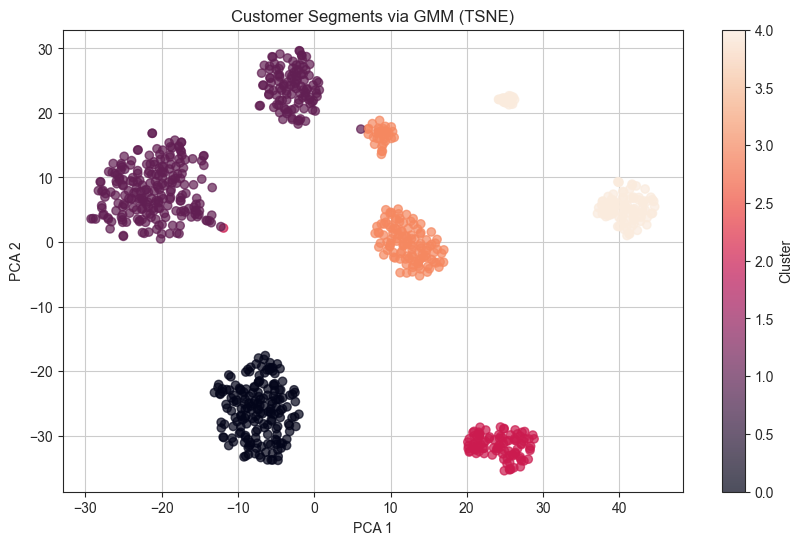

In [37]:
from sklearn.manifold import TSNE

# Reduce features to 2D
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_gmm)

# Plot clusters
plt.figure(figsize=(10, 6), dpi=100)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=customer_features['cluster'], alpha=0.7)
plt.title('Customer Segments via GMM (TSNE)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

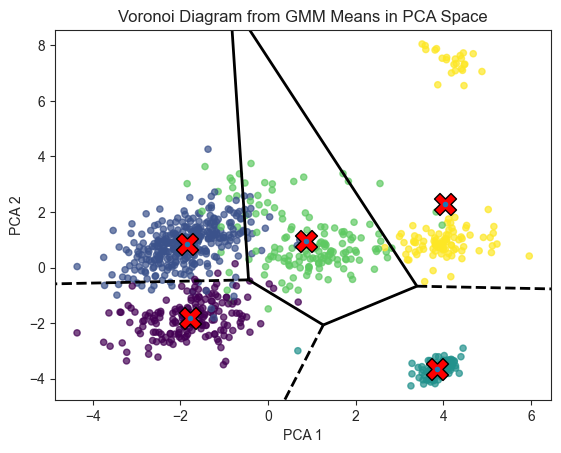

In [50]:
from scipy.spatial import Voronoi, voronoi_plot_2d

# Transform GMM means into the SAME PCA space
centers_pca = pca.transform(final_gmm.means_)

# Create Voronoi diagram
vor = Voronoi(centers_pca)

fig = voronoi_plot_2d(vor, show_vertices=False, line_colors="black", line_width=2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_features["cluster"], cmap="viridis", s=20, alpha=0.7)

# Plot GMM means
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="X", s=250, c="red", edgecolor="black")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.xlim(X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5)
plt.ylim(X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5)
plt.title("Voronoi Diagram from GMM Means in PCA Space")
plt.show()

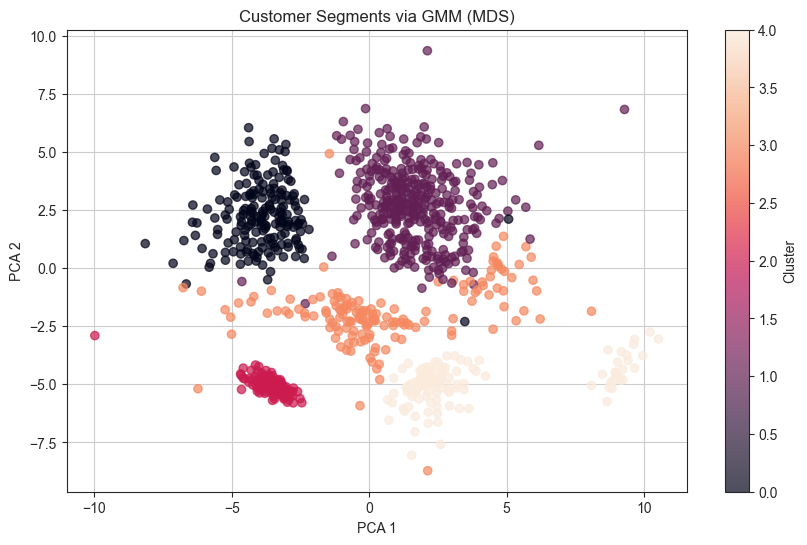

In [32]:
from sklearn.manifold import MDS

# Reduce features to 2D
mds = MDS(n_components=2)
X_mds = mds.fit_transform(X_gmm)

# Plot clusters
plt.figure(figsize=(10, 6), dpi=100)
scatter = plt.scatter(X_mds[:, 0], X_mds[:, 1], c=customer_features['cluster'], alpha=0.7)
plt.title('Customer Segments via GMM (MDS)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

In [ ]:
# Get the cluster summary
cluster_summary = customer_features.groupby('cluster').mean().round(2)
cluster_summary.to_csv('cluster_summary.csv', index=False)

cluster_summary

,spending_std,age,gender,HOM_entertainment_pct,HOM_food_dining_pct,HOM_gas_transport_pct,HOM_grocery_net_pct,HOM_grocery_pos_pct,HOM_health_fitness_pct,HOM_home_pct,HOM_kids_pets_pct,HOM_misc_net_pct,HOM_misc_pos_pct,HOM_personal_care_pct,HOM_shopping_net_pct,HOM_shopping_pos_pct,HOM_travel_pct,avg_tx_val_HOM_entertainment,avg_tx_val_HOM_gas_transport,avg_tx_val_HOM_health_fitness,avg_tx_val_HOM_home,avg_tx_val_HOM_misc_net,avg_tx_val_HOM_misc_pos,avg_tx_val_HOM_personal_care,avg_tx_val_HOM_shopping_net,online_spend_ratio
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1007.03,67.44,0.51,0.06,0.10,0.11,0.02,0.14,0.03,0.09,0.12,0.03,0.06,0.06,0.06,0.07,0.04,50.94,69.91,39.58,59.90,56.45,62.13,46.06,84.00,0.12
1,1185.56,56.95,0.34,0.06,0.04,0.14,0.01,0.19,0.06,0.08,0.08,0.06,0.04,0.06,0.07,0.07,0.03,49.97,60.10,50.36,49.97,61.86,54.83,48.28,51.99,0.14
2,1226.06,38.54,1.00,0.07,0.05,0.03,0.02,0.13,0.06,0.10,0.05,0.03,0.03,0.03,0.08,0.12,0.20,74.83,69.95,74.87,79.67,99.37,35.05,74.44,93.99,0.13
3,1330.88,34.53,0.89,0.08,0.05,0.13,0.04,0.10,0.07,0.09,0.08,0.05,0.07,0.03,0.07,0.09,0.03,58.05,67.55,57.81,57.42,54.22,61.37,35.06,60.66,0.17
4,1458.95,34.99,0.09,0.08,0.05,0.04,0.04,0.18,0.05,0.06,0.06,0.07,0.08,0.05,0.11,0.14,0.01,96.72,68.20,56.86,55.59,103.60,92.62,51.82,98.05,0.22


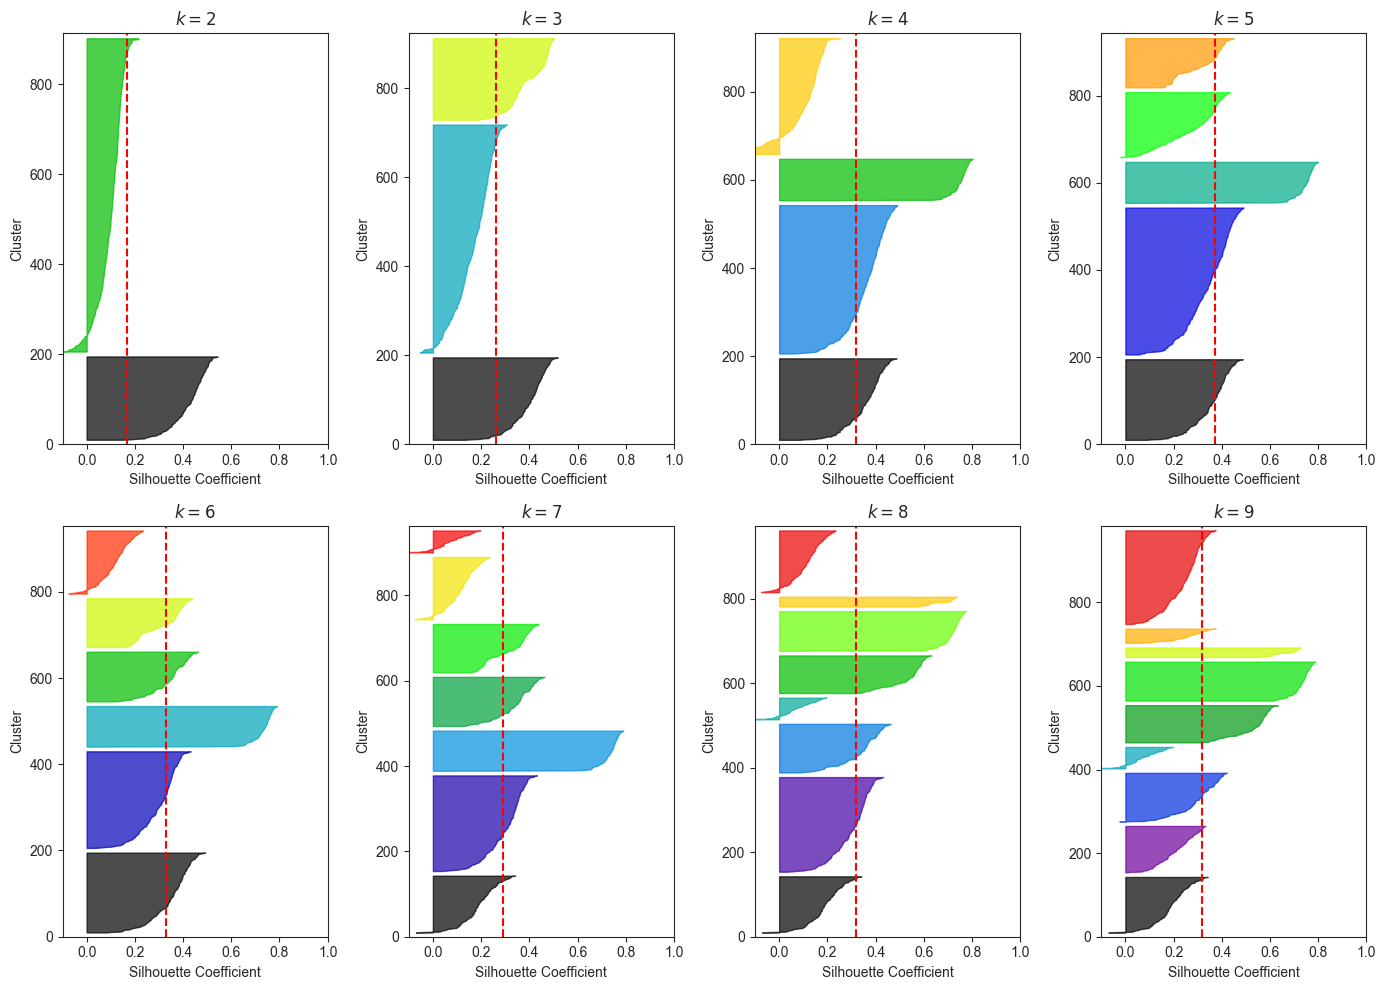

In [ ]:
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9] 

fig, axs = plt.subplots(2, 4, figsize=(14, 10), dpi=100)  # Adjust rows/cols if needed
axs = axs.flatten()  # So we can iterate easily

for idx, n_clusters in enumerate(range_n_clusters):
    ax = axs[idx]

    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    cluster_labels = gmm.fit_predict(X_gmm)

    silhouette_avg = silhouette_score(X_gmm, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_gmm, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()
        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_title(f"$k = {n_clusters}$")
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_gmm) + (n_clusters + 1) * 10])
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")

plt.tight_layout()
plt.show()


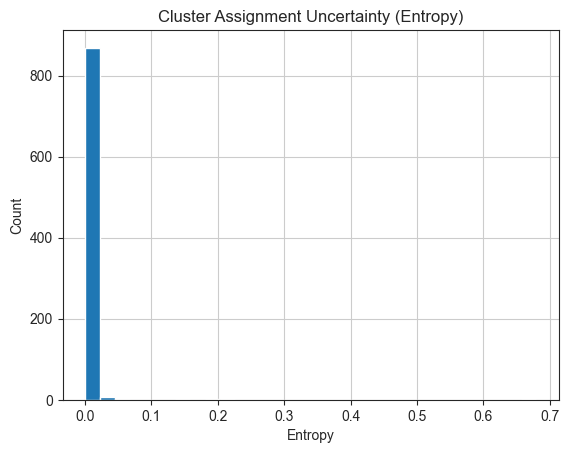

In [ ]:
probs = final_gmm.predict_proba(X_gmm)
entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)

plt.hist(entropy, bins=30)
plt.title("Cluster Assignment Uncertainty (Entropy)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.grid(True)
plt.show()


/var/folders/fy/zvqy_7710b1br2kprlbtbpf00000gn/T/ipykernel_83574/3239131272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=customer_features, palette='viridis', order=customer_features['cluster'].value_counts().index)


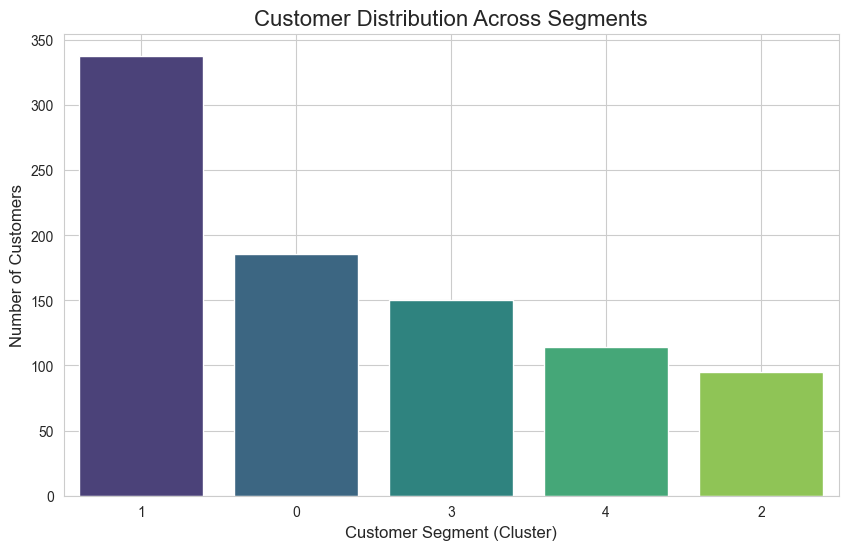

In [ ]:
sns.set_style('whitegrid')

# --- Create the Cluster Size Bar Chart ---
plt.figure(figsize=(10, 6), dpi=100)
sns.countplot(x='cluster', data=customer_features, palette='viridis', order=customer_features['cluster'].value_counts().index)
plt.title('Customer Distribution Across Segments', fontsize=16)
plt.xlabel('Customer Segment (Cluster)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.show()

/var/folders/fy/zvqy_7710b1br2kprlbtbpf00000gn/T/ipykernel_83574/2931878976.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('viridis', len(profile_scaled))(i)
/var/folders/fy/zvqy_7710b1br2kprlbtbpf00000gn/T/ipykernel_83574/2931878976.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('viridis', len(profile_scaled))(i)
/var/folders/fy/zvqy_7710b1br2kprlbtbpf00000gn/T/ipykernel_83574/2931878976.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()

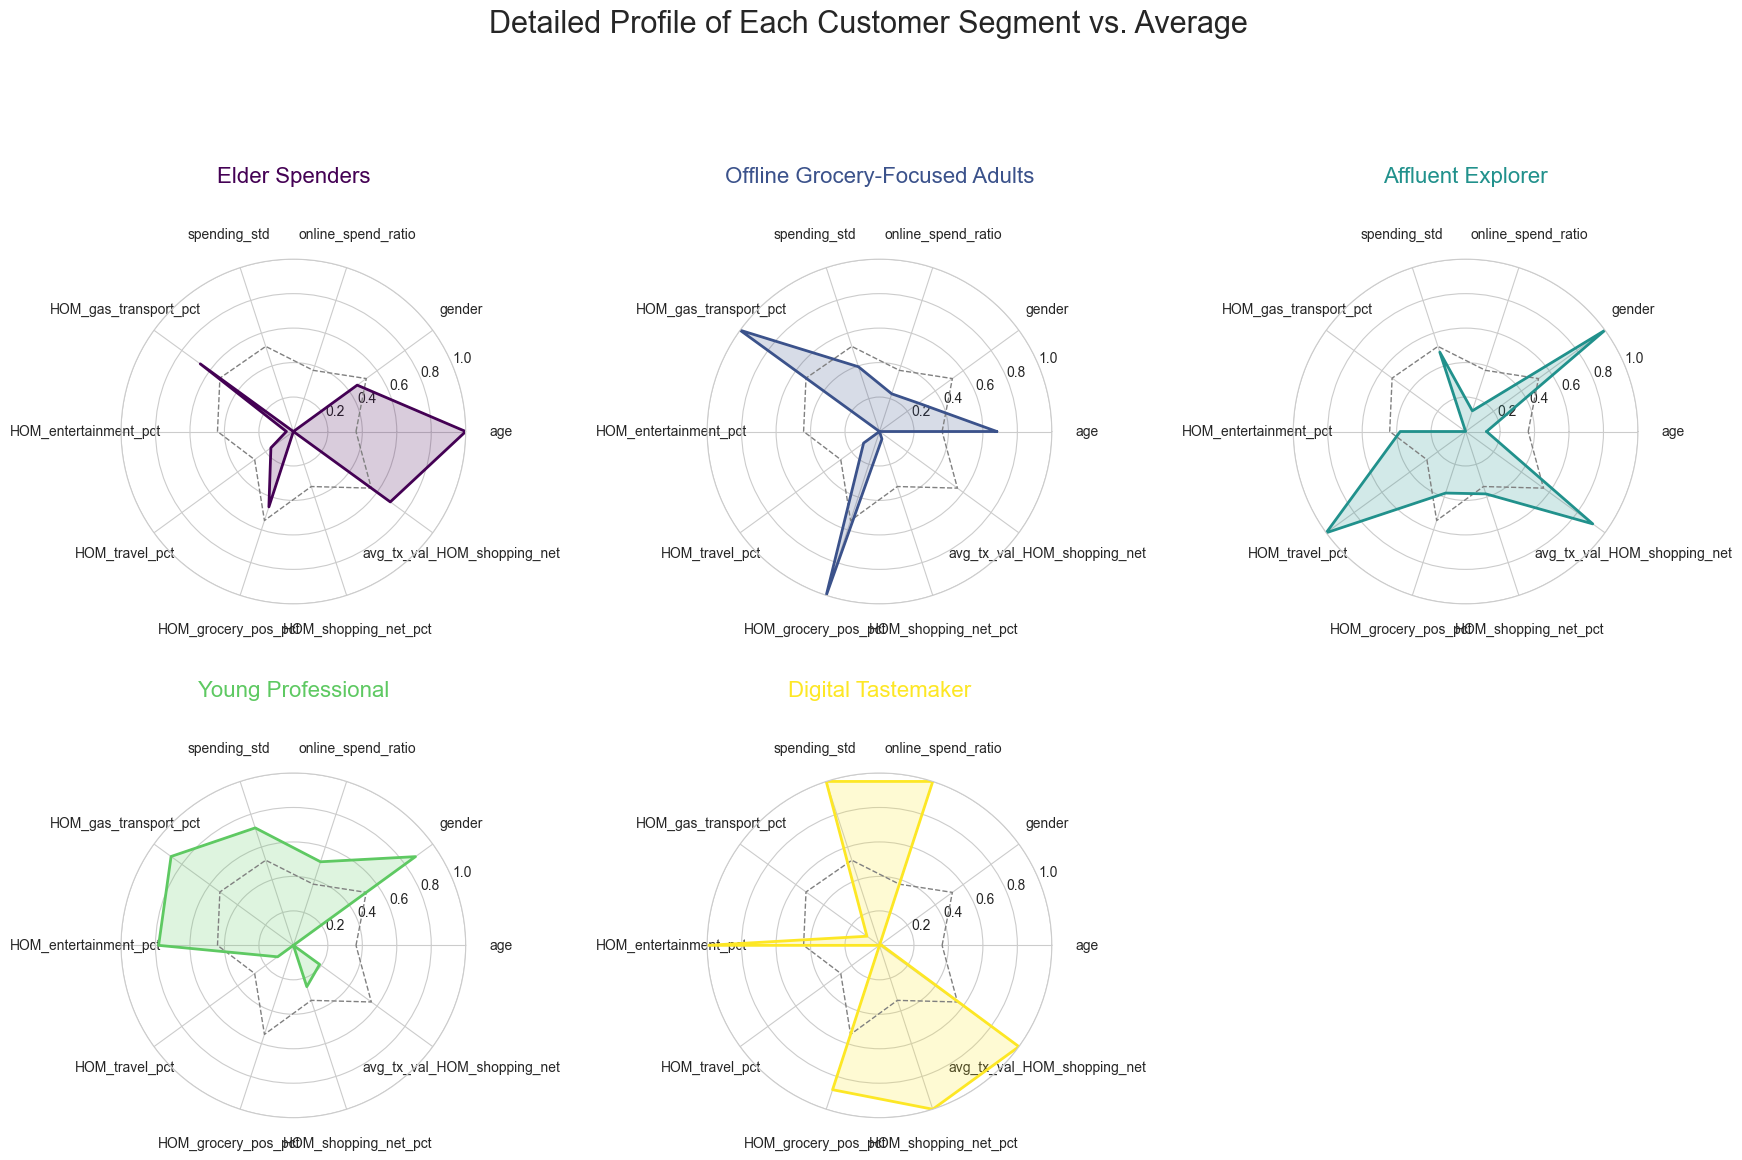

In [ ]:
features_for_radar = [
    'age',
    'gender',
    'online_spend_ratio',
    'spending_std',
    'HOM_gas_transport_pct',
    'HOM_entertainment_pct',
    'HOM_travel_pct',
    'HOM_grocery_pos_pct',
    'HOM_shopping_net_pct',
    'avg_tx_val_HOM_shopping_net'
]
personas = {
    0: "Elder Spenders",
    1: "Offline Grocery-Focused Adults",
    2: "Affluent Explorer",
    3: "Young Professional",
    4: "Digital Tastemaker"
}

# Create the cluster profile by grouping and taking the mean
cluster_profile = customer_features.groupby('cluster')[features_for_radar].mean()

# Scale the data for plotting
scaler = MinMaxScaler()
profile_scaled = pd.DataFrame(scaler.fit_transform(cluster_profile),
                              index=cluster_profile.index,
                              columns=cluster_profile.columns)

# Calculate the average profile for background context
average_profile = profile_scaled.mean().values

# Set up the radar chart plotting logic
labels = profile_scaled.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Complete the loop

# Subplots
fig, axes = plt.subplots(figsize=(18, 12), nrows=2, ncols=3,
                         subplot_kw=dict(polar=True))
fig.suptitle('Detailed Profile of Each Customer Segment vs. Average', fontsize=22)

# Flatten the axes array for easy iteration
axes_flat = axes.flatten()

# Helper function to plot a single radar chart
def plot_single_radar(ax, angles, values, avg_values, title, color):
    # Plot the average profile in the background
    avg_values_closed = np.concatenate((avg_values, [avg_values[0]]))
    ax.plot(angles, avg_values_closed, color='grey', linewidth=1, linestyle='dashed', label='Average')
    
    # Plot the specific cluster profile
    values_closed = np.concatenate((values, [values[0]]))
    ax.plot(angles, values_closed, color=color, linewidth=2, label=title)
    ax.fill(angles, values_closed, color=color, alpha=0.2)
    
    # Formatting
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.tick_params(axis='x', which='major', pad=15) # Add padding to labels
    ax.set_ylim(0, 1)
    ax.set_title(title, size=16, color=color, y=1.2)


# Loop through each cluster and create its subplot
for i, ax in enumerate(axes_flat[:len(profile_scaled)]):
    color = plt.cm.get_cmap('viridis', len(profile_scaled))(i)
    plot_single_radar(ax=ax,
                      angles=angles,
                      values=profile_scaled.loc[i].values,
                      avg_values=average_profile,
                      title=personas[i],
                      color=color)

# Hide any unused subplots
for i in range(len(profile_scaled), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Adjust layout to prevent titles from overlapping
plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
cluster_summary

,spending_std,age,gender,HOM_entertainment_pct,HOM_food_dining_pct,HOM_gas_transport_pct,HOM_grocery_net_pct,HOM_grocery_pos_pct,HOM_health_fitness_pct,HOM_home_pct,HOM_kids_pets_pct,HOM_misc_net_pct,HOM_misc_pos_pct,HOM_personal_care_pct,HOM_shopping_net_pct,HOM_shopping_pos_pct,HOM_travel_pct,avg_tx_val_HOM_entertainment,avg_tx_val_HOM_gas_transport,avg_tx_val_HOM_health_fitness,avg_tx_val_HOM_home,avg_tx_val_HOM_misc_net,avg_tx_val_HOM_misc_pos,avg_tx_val_HOM_personal_care,avg_tx_val_HOM_shopping_net,online_spend_ratio
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1007.03,67.44,0.51,0.06,0.10,0.11,0.02,0.14,0.03,0.09,0.12,0.03,0.06,0.06,0.06,0.07,0.04,50.94,69.91,39.58,59.90,56.45,62.13,46.06,84.00,0.12
1,1185.56,56.95,0.34,0.06,0.04,0.14,0.01,0.19,0.06,0.08,0.08,0.06,0.04,0.06,0.07,0.07,0.03,49.97,60.10,50.36,49.97,61.86,54.83,48.28,51.99,0.14
2,1226.06,38.54,1.00,0.07,0.05,0.03,0.02,0.13,0.06,0.10,0.05,0.03,0.03,0.03,0.08,0.12,0.20,74.83,69.95,74.87,79.67,99.37,35.05,74.44,93.99,0.13
3,1330.88,34.53,0.89,0.08,0.05,0.13,0.04,0.10,0.07,0.09,0.08,0.05,0.07,0.03,0.07,0.09,0.03,58.05,67.55,57.81,57.42,54.22,61.37,35.06,60.66,0.17
4,1458.95,34.99,0.09,0.08,0.05,0.04,0.04,0.18,0.05,0.06,0.06,0.07,0.08,0.05,0.11,0.14,0.01,96.72,68.20,56.86,55.59,103.60,92.62,51.82,98.05,0.22


In [ ]:
# silhouette_scores = []
# k_range = range(2, 10)

# for k in k_range:
#     kmeans = KMeans(n_clusters=k)
#     labels = kmeans.fit_predict(X_scaled)
#     score = silhouette_score(X_scaled, labels)
#     silhouette_scores.append(score)

# # Plot silhouette scores
# plt.figure(figsize=(10, 6), dpi=100)
# plt.bar(k_range, silhouette_scores)
# plt.title("Silhouette Score Method for Optimal k")
# plt.xlabel("Number of Clusters (k)")
# plt.ylabel("Silhouette Score")
# plt.grid(True, alpha=0.2)
# plt.tight_layout()
# plt.show()

# # Optional: Get best k
# best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
# print(f"Optimal number of clusters: {best_k}")

# kmeans = KMeans(n_clusters=6)
# customer_features['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# # Plot clusters
# plt.figure(figsize=(10, 6), dpi=100)
# sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=customer_features['cluster'], palette='tab10')
# plt.title("Customer Segments (PCA Projection)")
# plt.xlabel("PC 1")
# plt.ylabel("PC 2")
# plt.grid(True)

# plt.tight_layout()
# plt.show()